In [5]:
using Revise
using MajoranaPropagation
using MajoranaPropagation.QuantumChemistry
using PauliPropagation

using Plots 

In [6]:
# parse FCIDUMP file to get the Hamiltonian
filename = "path_to_fcidump"
filename = "STO3G_HF"
H = parse_fcidump(filename; min_coeff=5.e-10, remove_identity=true)
@show length(H)
n_orbitals = H.nsites

length(H) = 5734


10

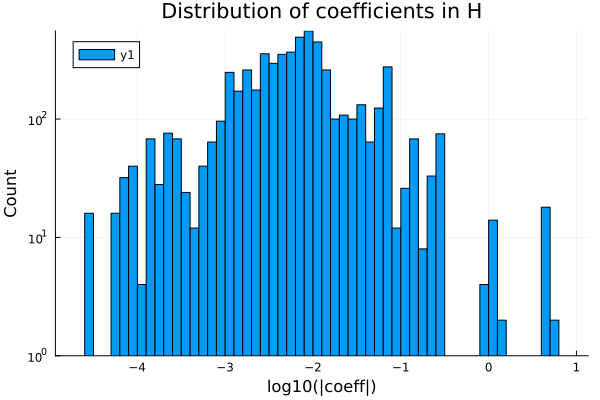

In [7]:
coeffs = log10.(abs.(coefficients(H)))
histogram(coeffs, bins=50, xlabel="log10(|coeff|)", ylabel="Count", title="Distribution of coefficients in H", yscale=:log10)

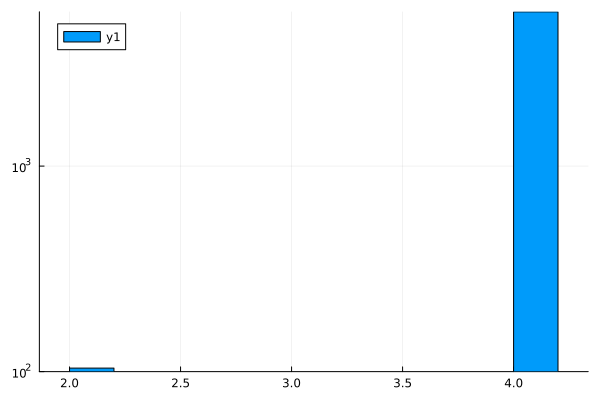

In [8]:
weights = get_weight.(MajoranaPropagation.majoranas(H))
histogram(weights, yscale=:log10)

In [9]:
up_electros = 1:2:n_orbitals
down_electros = 2:2:n_orbitals

overlap_with_fock_spinful(H, up_electros, down_electros, n_orbitals)

3.910859497436544 + 0.0im

In [10]:
dt = 0.05
n_steps = 10

circ = []
thetas = []

for (ms, coeff) in H
    push!(circ, MajoranaRotation(ms))
    push!(thetas, 2*dt*coeff)
end

In [11]:
obs = MajoranaSum(n_orbitals, :nup, 1) * MajoranaSum(n_orbitals, :nup, 3) * MajoranaSum(n_orbitals, :nup, 5)

obs_vals = zeros(n_steps+1)
obs_lengths = zeros(Int, n_steps+1)

obs_vals[1] = real(overlap_with_fock_spinful(obs, up_electros, down_electros, n_orbitals))
obs_lengths[1] = length(obs)

min_abs_coeff = 1.e-4

for i in 1:n_steps
    propagate!(circ, obs, thetas; min_abs_coeff=min_abs_coeff)
    obs_vals[i+1] = real(overlap_with_fock_spinful(obs, up_electros, down_electros, n_orbitals))
    obs_lengths[i+1] = length(obs)
    @show i, obs_lengths[i+1]
end


(i, obs_lengths[i + 1]) = (1, 4322)
(i, obs_lengths[i + 1]) = (2, 6159)
(i, obs_lengths[i + 1]) = (3, 8324)
(i, obs_lengths[i + 1]) = (4, 11265)
(i, obs_lengths[i + 1]) = (5, 14849)
(i, obs_lengths[i + 1]) = (6, 17445)
(i, obs_lengths[i + 1]) = (7, 20038)
(i, obs_lengths[i + 1]) = (8, 22220)
(i, obs_lengths[i + 1]) = (9, 24071)
(i, obs_lengths[i + 1]) = (10, 24920)


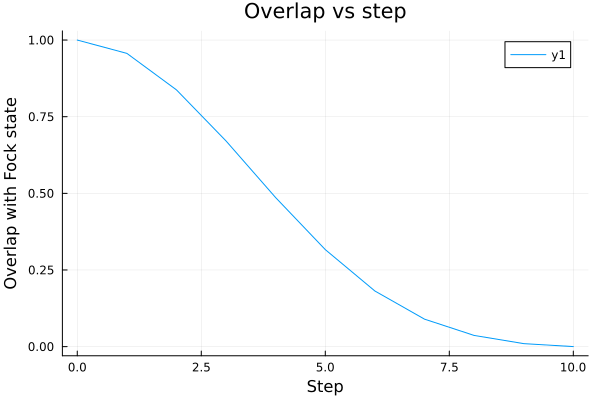

In [12]:
plot(0:n_steps, obs_vals, xlabel="Step", ylabel="Overlap with Fock state", title="Overlap vs step")

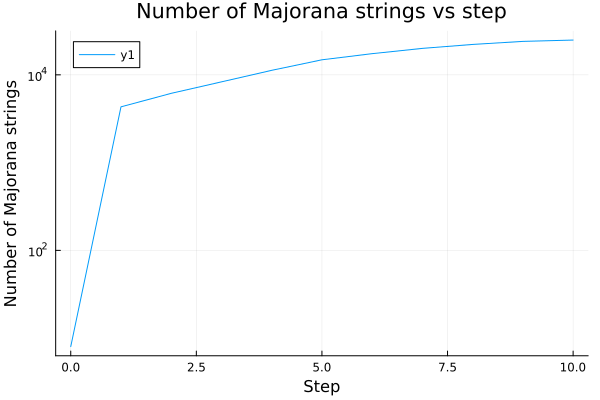

In [13]:
plot(0:n_steps, obs_lengths, xlabel="Step", ylabel="Number of Majorana strings", title="Number of Majorana strings vs step", yscale=:log10)